# Поиск объектов на изображениях

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Окружность, Прямоугольник, Треугольник

In [17]:
circle_img = cv2.imread('circle.png')
rectangle_img = cv2.imread('regtangl.png')
triangle_img = cv2.imread('triangl.png')
signs_img = cv2.imread('road.png')

def detect_shapes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY_INV)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result = image.copy()
    
    for i, contour in enumerate(contours):
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
        
        area = cv2.contourArea(contour)
        
        if area < 1000:
            continue
        
        shape_name = "Unknown"
        if len(approx) == 3:
            shape_name = "Triangle"
        elif len(approx) == 4:
            shape_name = "Rectangle"
        elif len(approx) > 6:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            if circularity > 0.7:
                shape_name = "Circle"
            else:
                shape_name = f"Polygon ({len(approx)})"
        else:
            shape_name = f"Polygon ({len(approx)})"
        
        cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)
    
    print(f"Figure: {shape_name}")
    
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Figure: Circle


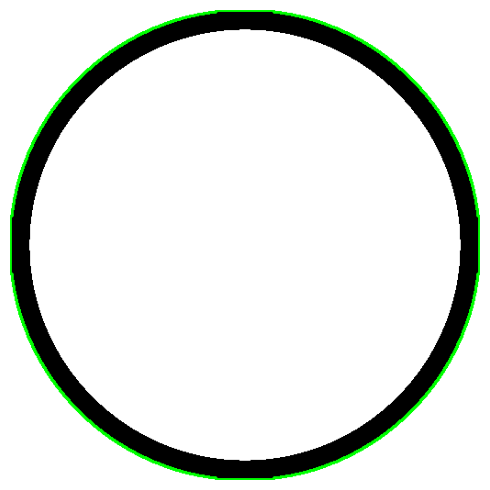

In [18]:
detect_shapes(circle_img)

Figure: Rectangle


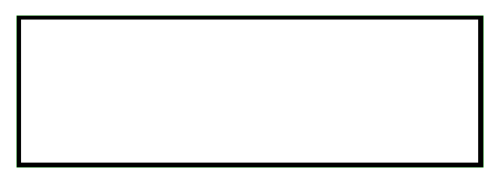

In [19]:
detect_shapes(rectangle_img)

Figure: Triangle


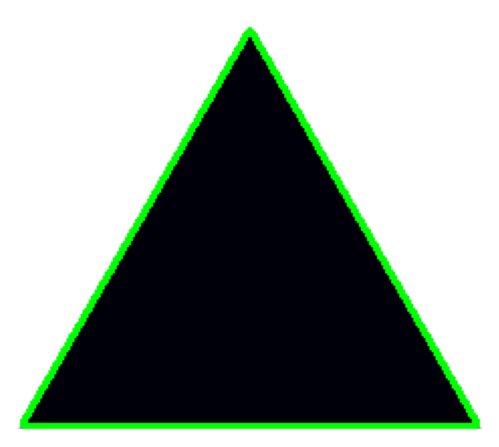

In [20]:
detect_shapes(triangle_img)

## Дорожные знаки

In [15]:
def detect_traffic_signs(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    gradient = np.sqrt(sobel_x**2 + sobel_y**2)
    gradient_uint8 = cv2.convertScaleAbs(gradient)
    
    threshold_value = 100
    _, edges = cv2.threshold(gradient_uint8, threshold_value, 255, cv2.THRESH_BINARY)
    
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    result = image.copy()
    sign_count = 0
        
    for i, contour in enumerate(contours):
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
        area = cv2.contourArea(contour)
        
        if area < 2000:
            continue
        
        shape_name = "Unknown"
        is_sign = False
        
        if len(approx) == 3:
            shape_name = "Triangle"
            is_sign = True
        elif len(approx) > 6:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            if circularity > 0.6:
                shape_name = "Circle"
                is_sign = True
            else:
                shape_name = f"Polygon ({len(approx)})"
        elif len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w)/h
            if 0.5 < aspect_ratio < 2.0:
                shape_name = "Square"
                is_sign = True
            else:
                shape_name = "Rectangle"
                is_sign = True
        
        if is_sign:
            sign_count += 1
            cv2.drawContours(result, [contour], -1, (0, 255, 0), 3)
            
            print(f"Road sign {sign_count}: {shape_name}, Perimeter = {perimeter}, Square = {area}")
        
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 4)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Road sign 1: Circle, Perimeter = 909.9625436067581, Square = 57997.5


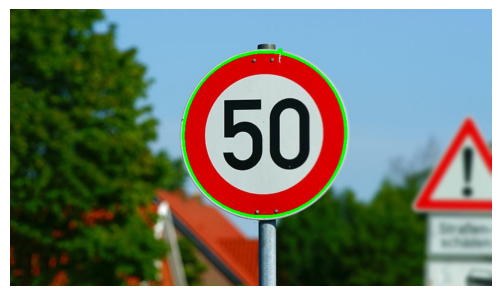

In [16]:
detect_traffic_signs(signs_img)

## Кэнни

Border 1: Length = 765.5361399650574, Square = 1029.5
Border 2: Length = 765.5361399650574, Square = 1028.5
Border 3: Length = 1564.645875453949, Square = 174755.0
Border 4: Length = 765.5361399650574, Square = 1028.5
Border 5: Length = 765.5361399650574, Square = 1027.5


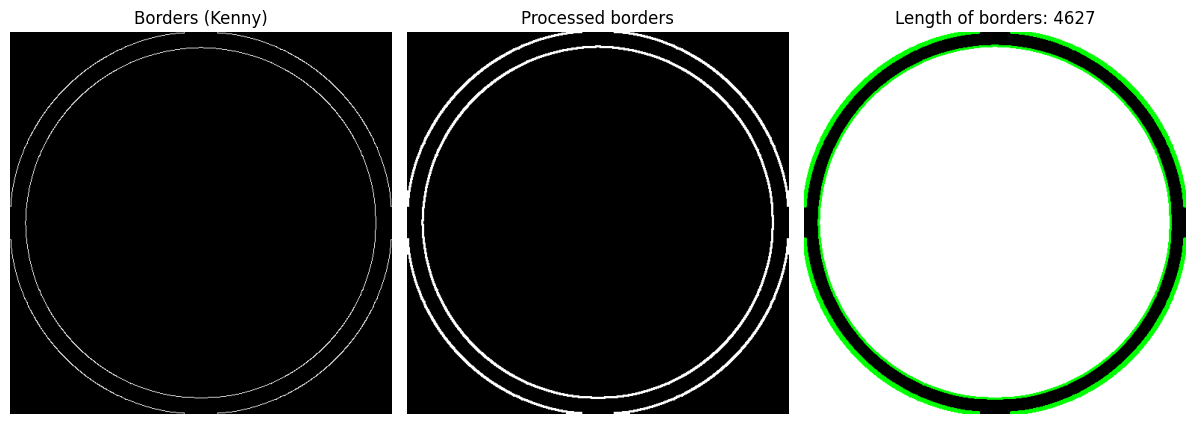

In [26]:
def measure_boundary_length(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    edges = cv2.Canny(blurred, 50, 150)
    
    kernel = np.ones((3, 3), np.uint8)
    dilated_edges = cv2.dilate(edges, kernel, iterations=2)
    eroded_edges = cv2.erode(dilated_edges, kernel, iterations=1)
    
    contours, _ = cv2.findContours(eroded_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    result = image.copy()
    total_length = 0
        
    boundary_lengths = []
    
    for i, contour in enumerate(contours):
        length = cv2.arcLength(contour, True)
        area = cv2.contourArea(contour)
        
        if length < 50:
            continue
        
        boundary_lengths.append((i+1, length, area))
        total_length += length
        
        cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)

    for idx, length, area in boundary_lengths:
        print(f"Border {idx}: Length = {length}, Square = {area}")
        
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 5, 3)
    plt.imshow(edges, cmap='gray')
    plt.title("Borders (Kenny)")
    plt.axis('off')
    
    plt.subplot(1, 5, 4)
    plt.imshow(eroded_edges, cmap='gray')
    plt.title("Processed borders")
    plt.axis('off')
    
    plt.subplot(1, 5, 5)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Length of borders: {total_length:.0f}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

measure_boundary_length(circle_img)